## Ensemble Learning for Network Intrusion Detection using CICIDS2017

Bu çalışmanın amacı, CICIDS2017 veri seti üzerinde farklı ensemble learning yöntemlerini uygulayarak ağ saldırılarının tespitindeki performanslarını karşılaştırmaktır.

Bu notebook kapsamında aşağıdaki yöntemler incelenecektir:

- Random Forest (Bagging)
- XGBoost (Boosting)
- LightGBM (Boosting)
- Stacking Classifier

Modeller; doğruluk (Accuracy), kesinlik (Precision), duyarlılık (Recall), F1-Score ve Confusion Matrix metrikleri kullanılarak değerlendirilecektir.

Projede kullanacağımız tüm kütüphaneleri yüklüyoruz.

In [3]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Makine öğrenmesi modelleri
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Meta Learner
from sklearn.linear_model import LogisticRegression

# Performans değerlendirme
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Uyarıları gizlemek için
import warnings
warnings.filterwarnings("ignore")

Bu projede veri temizleme ile uğraşmayacağız. Çünkü o kısmı önceki projede (network-intrusion-detection-ml) tamamladık.

Ön işleme aşamasında hazırladığımız eğitim ve test verilerini projeye alıyoruz.

In [4]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

Y tek sütunlu bir DataFrame. Sklearn'de daha rahat çalışmak için Series'e çeviriyoruz.

In [5]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

Verileri kontrol ediyoruz.

In [6]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (452465, 78)
X_test : (113117, 78)
y_train: (452465,)
y_test : (113117,)


In [7]:
X_train.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,53,62844,2,2,64,120,32,32,32.0,0.0,...,1,32,0.0,0.0,0,0,0.0,0.0,0,0
1,53,30845,2,2,62,228,31,31,31.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
2,53,60471,1,1,47,79,47,47,47.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,53,159,2,2,80,112,40,40,40.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
4,56621,7,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0


In [8]:
y_train.head()

0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64

Modeli eğitmeden önce eğitim verisindeki sınıf dağılımını kontrol ediyoruz.

Çünkü makine öğrenmesinde sadece verinin boyutu değil, sınıfların dağılımı da çok önemlidir.

Örneğin eğer verilerin %95'i "Normal Trafik" ise model sadece "Normal" diyerek yüksek accuracy elde edebilir.
Ama saldırıları kaçırabilir. Bu yüzden her zaman eğitimden önce hedef değişkeni kontrol ederiz.

In [9]:
class_distribution = y_train.value_counts().sort_index()

print(class_distribution)

Label
0     363418
1        310
2      20484
3       1647
4      36818
5        880
6        927
7       1270
8          2
9          6
10     25411
11       943
12       241
13         3
14       105
Name: count, dtype: int64


In [10]:
class_percentage = y_train.value_counts(normalize=True).sort_index() * 100

print(class_percentage.round(2))

Label
0     80.32
1      0.07
2      4.53
3      0.36
4      8.14
5      0.19
6      0.20
7      0.28
8      0.00
9      0.00
10     5.62
11     0.21
12     0.05
13     0.00
14     0.02
Name: proportion, dtype: float64


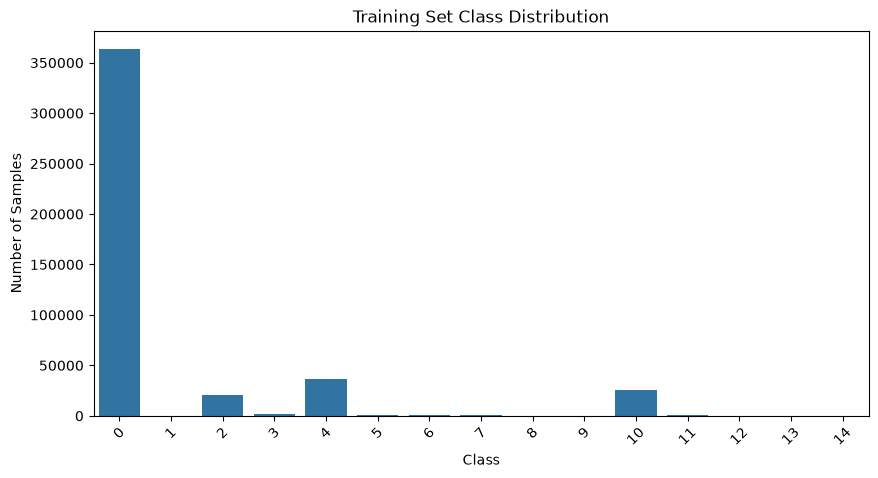

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=class_distribution.index.astype(str),
    y=class_distribution.values
)

plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

Önceki projede Label Encoding yaptığımız için burada yapmıyoruz ama kısa bir açıklama:
Label Encoding neden yapılır? Makine öğrenmesi algoritmaları metinleri (string) doğrudan işleyemez. Bu yüzden sınıf isimlerini sayılara dönüştürürüz.

## Random Forest (Bagging)

Amaç ilk temel (base) modelimizi oluşturmak ve performansını görmek.

Bagging'in en başarılı ve en yaygın kullanılan örneklerinden biri olduğu için Random Forest ile başlıyoruz.

Önce modeli oluşturuyoruz.

n_estimators=100 -> decision tree sayısı

random_state=42 -> her çalıştırmada aynı rastgelelik kullanılır ve sonuçlar tekrar üretilebilir (reproducible) olur.

n_jobs=-1 -> bilgisayarda olan çekirdeklerin tümü kullanılır böylece eğitim çok daha hızlı olur.

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

Modeli eğitiyoruz.

Model veriyi görüyor. 100 farklı Decision Tree oluşturuyor. Her ağaç bootstrap örnekleriyle eğitiliyor. Bagging işlemi tamamlanıyor. Artık model öğrendi.

In [13]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

Yeni veriler için tahmin üretiyoruz.

In [14]:
rf_predictions = rf_model.predict(X_test)

In [15]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.9982


Bir önceki projede her bir model için ayrı ayrı performans metriklerini hesaplamıştık. Bu sefer burada bir fonksiyon yazacağız ve ileride bu fonksiyonu kullanarak hesaplama yapacağız.

In [16]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Verilen modelin performans metriklerini hesaplar ve ekrana yazdırır.
    """

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [17]:
evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=rf_predictions
)


Model: Random Forest
Accuracy : 0.9982
Precision: 0.9982
Recall   : 0.9982
F1-Score : 0.9982

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90855
           1       0.86      0.78      0.82        78
           2       1.00      1.00      1.00      5121
           3       1.00      0.99      0.99       412
           4       1.00      1.00      1.00      9205
           5       1.00      0.99      1.00       220
           6       1.00      1.00      1.00       232
           7       1.00      1.00      1.00       317
           9       0.00      0.00      0.00         1
          10       0.99      1.00      0.99      6353
          11       1.00      0.99      1.00       236
          12       0.76      0.73      0.75        60
          13       0.00      0.00      0.00         1
          14       0.43      0.38      0.41        26

    accuracy                           1.00    113117
   macro avg    

## XGBoost (Boosting)

Amaç boosting yaklaşımını kullanan ilk modelimizi eğitmek ve Random Forest ile karşılaştırmak.

Her yeni ağaç, bir önceki ağacın yaptığı hataları düzeltmeye çalışıyor. İşte buna Boosting diyoruz.

Modeli oluşturuyoruz. 

eval_metric="mlogloss" -> parametresi, makine öğrenmesi modellerinde çok sınıflı sınıflandırma (multi-class classification) problemlerinin başarısını ölçmek için kullanılır.

In [18]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss"
)

Modeli eğitelim sonrasında tahmin üretelim.

In [19]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [20]:
xgb_predictions = xgb_model.predict(X_test)

Fonksiyonu çağırarak değerlendiriyoruz.

In [21]:
evaluate_model(
    model_name="XGBoost",
    y_true=y_test,
    y_pred=xgb_predictions
)


Model: XGBoost
Accuracy : 0.9983
Precision: 0.9983
Recall   : 0.9983
F1-Score : 0.9983

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90855
           1       0.80      0.78      0.79        78
           2       1.00      1.00      1.00      5121
           3       0.97      0.98      0.97       412
           4       1.00      1.00      1.00      9205
           5       0.99      0.99      0.99       220
           6       1.00      0.99      0.99       232
           7       1.00      1.00      1.00       317
           9       0.00      0.00      0.00         1
          10       0.99      1.00      1.00      6353
          11       1.00      0.99      0.99       236
          12       0.75      0.73      0.74        60
          13       0.00      0.00      0.00         1
          14       0.33      0.38      0.36        26

    accuracy                           1.00    113117
   macro avg       0.7

## LightGBM

LightGBM de Boosting ailesinden. Tek fark, algoritmanın çalışma şekli.

Modeli oluşturuyoruz.

verbose=-1 -> Bu sadece eğitim sırasında çıkan bilgi mesajlarını kapatır. Modelin başarısını etkilemez; notebook'un daha temiz görünmesini sağlar.

In [22]:
lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=len(np.unique(y_train)),
    n_estimators=100,
    random_state=42,
    verbose=-1
)

Modeli eğitip tahmin yapıyoruz.

In [23]:
lgbm_model.fit(X_train, y_train)

,objective,'multiclass'
,random_state,42
,num_class,15
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,class_weight,None


In [24]:
lgbm_predictions = lgbm_model.predict(X_test)

Değerlendirme fonksiyonunu çağırıyoruz.

In [25]:
evaluate_model(
    model_name="LightGBM",
    y_true=y_test,
    y_pred=lgbm_predictions
)


Model: LightGBM
Accuracy : 0.8247
Precision: 0.7730
Recall   : 0.8247
F1-Score : 0.7920

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90     90855
           1       0.00      0.00      0.00        78
           2       0.32      0.37      0.34      5121
           3       0.00      0.00      0.00       412
           4       0.89      0.50      0.64      9205
           5       0.00      0.00      0.00       220
           6       0.00      0.00      0.00       232
           7       0.00      0.00      0.00       317
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00      6353
          11       0.00      0.00      0.00       236
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy                           0.82    113117
   macro avg       0.

LightGBM, varsayılan hiperparametrelerle bu veri setinde Random Forest ve XGBoost kadar başarılı performans göstermemiştir.

## Stacking Classifier

Meta Learner: 

Random Forest -> DDoS
XGBoost -> BENIGN
LightGBM -> DDoS

Logistic Regression bunların tahminlerine bakıyor ve eğitim sırasında şunu öğreniyor:

"RF ve XGB aynı fikirdeyse genelde doğru oluyor." veya "LightGBM bu veri tipinde çok hata yapıyor." gibi ilişkileri öğreniyor.

Yani sadece oy saymıyor. Hangi modele ne kadar güveneceğini de öğreniyor. İşte Stacking'i Voting'den ayıran en önemli nokta bu.

In [26]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators: bizim temel modellerimizin listesi.

Örneğin ("rf", rf_model) demek "Random Forest'ı kullan." anlamına geliyor.

In [27]:
estimators = [
    ("rf", rf_model),
    ("xgb", xgb_model),
    ("lgbm", lgbm_model)
]

Stacking modelini oluşturuyoruz.

Parametreler:

- estimators=estimators -> Biraz önce oluşturduğumuz liste. İçindeki üç modeli kullanacak.

- final_estimator=LogisticRegression(max_iter=1000) -> Meta model. max_iter=1000 yazmamızın nedeni, Logistic Regression bazen varsayılan iterasyon sayısında yakınsamayabiliyor. 1000 yazarak bunun önüne geçiyoruz.

- cv=5 -> Cross Validation. Veriyi 5 parçaya ayırıp dördünü eğitim birini test verisi yapıyor. Her parça sırayla test oluyor. Böylece Logistic Regression, modelin daha önce görmediği veriler üzerindeki tahminleri öğreniyor. Yani daha güvenilir öğreniyor. Bu yüzden Stacking'de cv çok önemli.

- n_jobs=-1 -> Tüm işlemci çekirdeklerini kullan.

In [28]:
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

Modeli eğitiyoruz.

İçeride:

- Random Forest
- XGBoost
- LightGBM
- Logistic Regression

hep birlikte çalışıyor.

Sonrasında tahmin ediyor.

In [29]:
stacking_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](15,)","[ 0, 1, 2,...,12,13,14]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...), LGBMClassifie... verbose=-1)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit

In [30]:
stacking_predictions = stacking_model.predict(X_test)

In [31]:
evaluate_model(
    model_name="Stacking",
    y_true=y_test,
    y_pred=stacking_predictions
)


Model: Stacking
Accuracy : 0.9983
Precision: 0.9982
Recall   : 0.9983
F1-Score : 0.9982

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90855
           1       0.80      0.86      0.83        78
           2       1.00      1.00      1.00      5121
           3       0.99      0.99      0.99       412
           4       1.00      1.00      1.00      9205
           5       1.00      0.99      0.99       220
           6       1.00      1.00      1.00       232
           7       1.00      1.00      1.00       317
           9       0.00      0.00      0.00         1
          10       0.99      1.00      0.99      6353
          11       1.00      0.99      1.00       236
          12       0.71      0.93      0.81        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy                           1.00    113117
   macro avg       0.

Stacking modeli, farklı algoritmaların güçlü yönlerini birleştirmek amacıyla oluşturulmuştur. Genel doğruluk oranı XGBoost ile benzer seviyede gerçekleşmiştir. Bununla birlikte bazı az örnekli sınıflarda (örneğin Label 1 ve Label 12) geri çağırma (Recall) değerlerinde iyileşme gözlenmiştir. Ancak LightGBM'nin varsayılan parametrelerle düşük performans göstermesi nedeniyle Stacking modelinin genel performansı belirgin şekilde artmamıştır.

## Dört Modelin Karşılaştırma Tablosu

In [33]:
results = []

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "Stacking"],
    "Accuracy": [0.9982, 0.9983, 0.8247, 0.9983],
    "Precision": [0.9982, 0.9983, 0.7730, 0.9982],
    "Recall": [0.9982, 0.9983, 0.8247, 0.9983],
    "F1-Score": [0.9982, 0.9983, 0.7920, 0.9982]
})

results
    

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9982,0.9982,0.9982,0.9982
1,XGBoost,0.9983,0.9983,0.9983,0.9983
2,LightGBM,0.8247,0.7730,0.8247,0.7920
3,Stacking,0.9983,0.9982,0.9983,0.9982


XGBoost ve Stacking modelleri en yüksek doğruluk oranına ulaşmıştır. Bununla birlikte Stacking modeli farklı algoritmaların güçlü yönlerini birleştirmesi nedeniyle ensemble learning yaklaşımını temsil eden en kapsamlı model olarak değerlendirilmiştir. LightGBM ise varsayılan hiperparametrelerle diğer modellere göre daha düşük performans göstermiştir.

## Feature Importance

Bu analiz, Random Forest modelinin karar verirken hangi özelliklere daha fazla önem verdiğini göstermektedir. Özellik önemleri sayesinde saldırı tespitinde en etkili ağ trafiği özellikleri belirlenebilir.

In [37]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
41,Packet Length Std,0.056832
42,Packet Length Variance,0.056812
39,Max Packet Length,0.048138
54,Avg Bwd Segment Size,0.045356
52,Average Packet Size,0.044265
0,Destination Port,0.041749
63,Subflow Fwd Bytes,0.036678
10,Bwd Packet Length Max,0.036651
13,Bwd Packet Length Std,0.032152
5,Total Length of Bwd Packets,0.030579


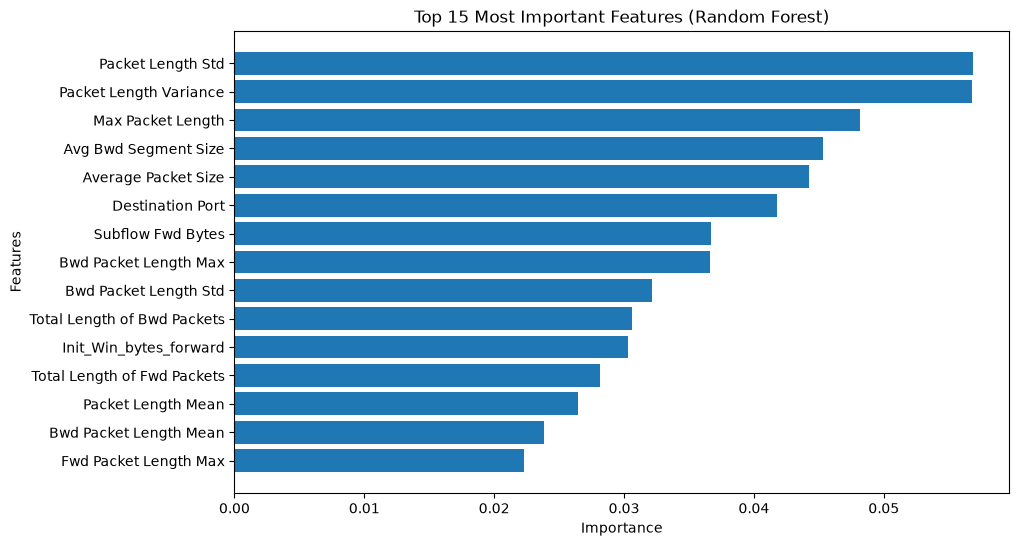

In [38]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

## Confusion Matrix

Bunu Stacking modeli üzerinden yapıyoruz.

Confusion Matrix, modelin hangi sınıfları doğru tahmin ettiğini ve hangi sınıflar arasında karışıklık yaşadığını görselleştirmek amacıyla kullanılmıştır.

Not: 15 sınıf olduğu için grafik oldukça yoğun görünebilir. Bu normaldir.

<Figure size 1200x1200 with 0 Axes>

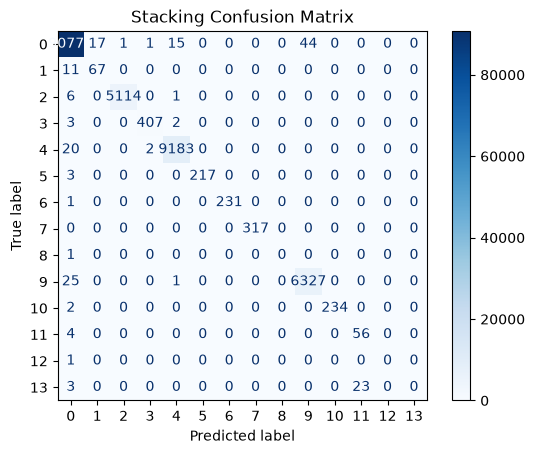

In [39]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    stacking_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

plt.figure(figsize=(12,12))
disp.plot(cmap="Blues")
plt.title("Stacking Confusion Matrix")
plt.show()

Bu çalışmada CICIDS2017 veri seti üzerinde Bagging, Boosting ve Stacking tabanlı ensemble learning yöntemleri uygulanmıştır. Random Forest, XGBoost, LightGBM ve Stacking modelleri karşılaştırılmıştır. Sonuçlar incelendiğinde XGBoost ve Stacking modellerinin en yüksek performansı gösterdiği, LightGBM modelinin ise varsayılan hiperparametrelerle daha düşük başarı elde ettiği görülmüştür. Ensemble yöntemlerinin özellikle yüksek boyutlu ve dengesiz siber güvenlik veri setlerinde başarılı sonuçlar üretebildiği gözlemlenmiştir.